### Dataset

In [1]:
!ls /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset
print("")
!ls /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train

VisDrone2019-DET-test-challenge  VisDrone2019-DET-train  visdrone.yaml
VisDrone2019-DET-test-dev	 VisDrone2019-DET-val

images	labels


### Filtering Unnecessary Classes

In [2]:
import os
import glob

def filter_yolo_classes(input_dir, output_dir):
    """
    Filters existing YOLO labels.
    Original VisDrone YOLO Classes: 0: pedestrian, 1: people, 2: bicycle, 3: car...
    Our Target Classes: 0: Human (combines 0 & 1), 1: Car (original 3)
    """
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)
    
    label_paths = glob.glob(os.path.join(input_dir, 'labels', '*.txt'))
    print(f"Processing {len(label_paths)} files in {input_dir}...")
    
    valid_files_count = 0
    
    for label_path in label_paths:
        filename = os.path.basename(label_path)
        img_filename = filename.replace('.txt', '.jpg')
        img_path = os.path.join(input_dir, 'images', img_filename)
        
        if not os.path.exists(img_path): 
            continue
            
        valid_boxes = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                
                target_cls = -1
                # Map pedestrian (0) and people (1) to Human (0)
                if cls_id in [0, 1]: 
                    target_cls = 0
                # Map car (3) to Car (1)
                elif cls_id == 3: 
                    target_cls = 1
                    
                if target_cls != -1:
                    # Keep the normalized coordinates exactly as they are
                    valid_boxes.append(f"{target_cls} {' '.join(parts[1:])}\n")
        
        # Only save if the image actually contains a human or a car
        if valid_boxes:
            valid_files_count += 1
            # 1. Write the new filtered label
            with open(os.path.join(output_dir, 'labels', filename), 'w') as f:
                f.writelines(valid_boxes)
            
            # 2. Create a symlink to the image (instant, uses 0 disk space)
            target_img = os.path.join(output_dir, 'images', img_filename)
            if not os.path.exists(target_img):
                os.symlink(img_path, target_img)
                
    print(f"Done! Kept {valid_files_count} images containing humans/cars.")

# Define your paths
base_input = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset'
base_output = '/kaggle/working/custom_visdrone'

# Run the filter for Train and Val sets
filter_yolo_classes(f'{base_input}/VisDrone2019-DET-train', f'{base_output}/train')
filter_yolo_classes(f'{base_input}/VisDrone2019-DET-val', f'{base_output}/val')

Processing 6471 files in /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train...
Done! Kept 6468 images containing humans/cars.
Processing 548 files in /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val...
Done! Kept 548 images containing humans/cars.


### creating data.yaml for the custom visdrone data

In [8]:
import yaml

data_yaml = {
    'train': '/kaggle/working/custom_visdrone/train/images',
    'val': '/kaggle/working/custom_visdrone/val/images',
    'test': '/kaggle/working/custom_visdrone/test/images',
    'nc': 2,
    'names': ['Human', 'Car']
}

with open('/kaggle/working/custom_visdrone/data.yaml', 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print("data.yaml created successfully!")

data.yaml created successfully!


### Inference and Counting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.0 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 2 packages in 250ms
Prepared 1 package in 86ms
Installed 1 package in 3ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


0: 384x640 1 Human, 28 Cars, 48.3ms
Speed: 10.9ms preprocess, 48.3ms inference, 37.4ms postprocess per image at shape (1, 3, 384, 640)


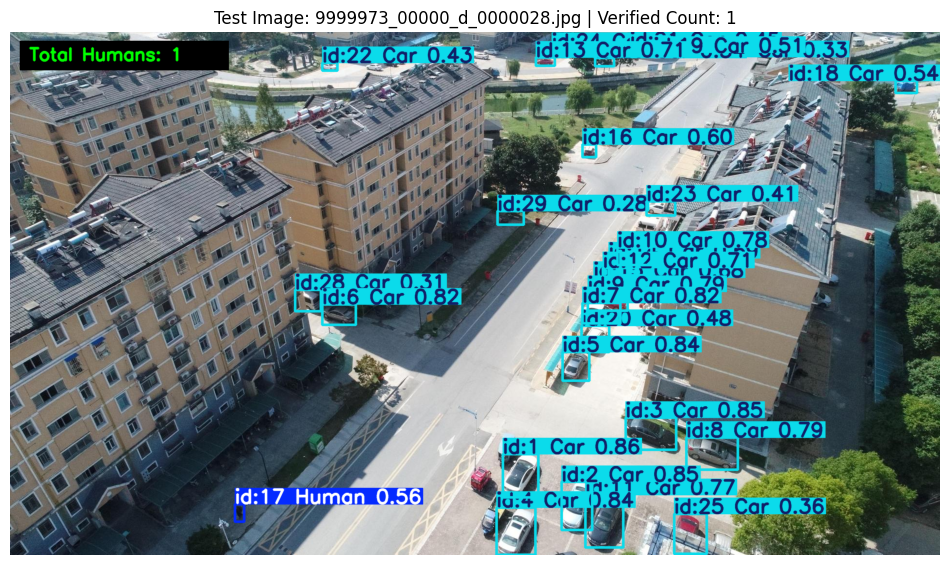


0: 384x640 2 Humans, 12 Cars, 10.6ms
Speed: 2.2ms preprocess, 10.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


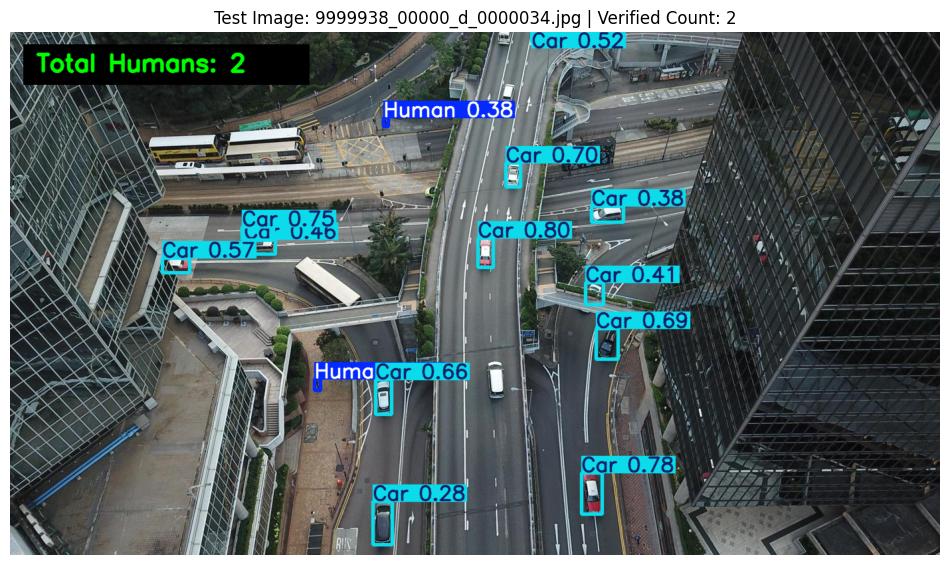


0: 384x640 40 Humans, 10.6ms
Speed: 2.0ms preprocess, 10.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


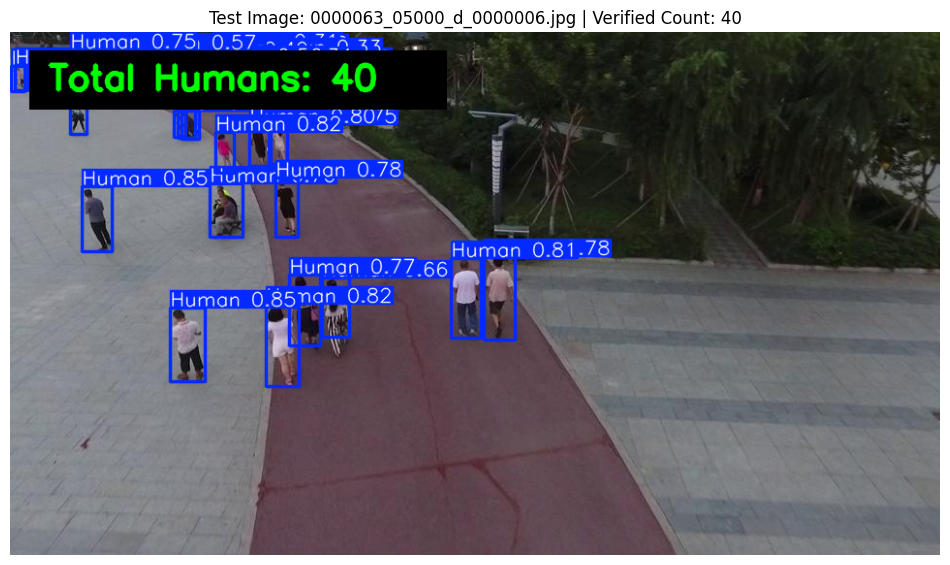

Processing complete! Images saved to /kaggle/working/inference_outputs ready for GitHub.


In [5]:
!pip install ultralytics

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import glob
import os

# loading custom trained YOLOv8 model
model_path = '/kaggle/input/models/samiulhossen/custom-yolov8s/other/default/1/best.pt' 
model = YOLO(model_path, task='detect')

test_images_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/images'
# testing the first 3 images to verify the logic works
test_images = glob.glob(os.path.join(test_images_dir, '*.jpg'))[:3] 

output_dir = '/kaggle/working/inference_outputs'
os.makedirs(output_dir, exist_ok=True)

for img_path in test_images:
    img = cv2.imread(img_path)
    img_name = os.path.basename(img_path)
    
    # runing Inference with ByteTrack enabled
    # conf=0.25 filters out weak predictions to keep the count accurate
    results = model.track(img, persist=True, tracker="bytetrack.yaml", conf=0.25)
    result = results[0]

    human_count = 0
    if result.boxes is not None:
        for box in result.boxes:
            # mapped Human to class ID 0 during the preprocessing phase
            if int(box.cls[0]) == 0:
                human_count += 1
                
    # visualization
    annotated_img = result.plot()
    
    # adding the custom Human Count overlay
    text = f"Total Humans: {human_count}"
    font = cv2.FONT_HERSHEY_SIMPLEX
    # drawing a black background rectangle for the text to make it readable
    cv2.rectangle(annotated_img, (20, 20), (450, 80), (0, 0, 0), -1) 
    cv2.putText(annotated_img, text, (40, 60), font, 1.2, (0, 255, 0), 3, cv2.LINE_AA)
    
    # saving the high-res image to disk
    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, annotated_img)
    
    # displaying it right here in the notebook
    annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_img_rgb)
    plt.axis('off')
    plt.title(f"Test Image: {img_name} | Verified Count: {human_count}")
    plt.show()

print(f"Processing complete! Images saved to {output_dir} ready for GitHub.")

### Applying preprocessing for the test set

In [10]:
import os
import glob
import yaml
from ultralytics import YOLO

# Define the filtering function
def filter_yolo_classes(input_dir, output_dir):
    os.makedirs(os.path.join(output_dir, 'images'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels'), exist_ok=True)
    
    label_paths = glob.glob(os.path.join(input_dir, 'labels', '*.txt'))
    print(f"Filtering {len(label_paths)} files in {input_dir}...")
    
    valid_files_count = 0
    for label_path in label_paths:
        filename = os.path.basename(label_path)
        img_filename = filename.replace('.txt', '.jpg')
        img_path = os.path.join(input_dir, 'images', img_filename)
        
        if not os.path.exists(img_path): continue
            
        valid_boxes = []
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                
                target_cls = -1
                if cls_id in [0, 1]: target_cls = 0      # Human
                elif cls_id == 3: target_cls = 1         # Car
                    
                if target_cls != -1:
                    valid_boxes.append(f"{target_cls} {' '.join(parts[1:])}\n")
        
        if valid_boxes:
            valid_files_count += 1
            with open(os.path.join(output_dir, 'labels', filename), 'w') as f:
                f.writelines(valid_boxes)
            
            target_img = os.path.join(output_dir, 'images', img_filename)
            if not os.path.exists(target_img):
                os.symlink(img_path, target_img)
                
    print(f"Filtered {valid_files_count} test images successfully.")

# running the filter specifically on the test-dev set
base_input = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev'
base_output = '/kaggle/working/custom_visdrone/test'
filter_yolo_classes(base_input, base_output)

Filtering 1610 files in /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev...
Filtered 1603 test images successfully.
data.yaml updated for testing.


### updating data.yaml

In [12]:
import yaml

data_yaml = {
    'train': '/kaggle/working/custom_visdrone/train/images',
    'val': '/kaggle/working/custom_visdrone/val/images',
    'test': '/kaggle/working/custom_visdrone/test/images',
    'nc': 2,
    'names': ['Human', 'Car']
}

with open('/kaggle/working/custom_visdrone/data.yaml', 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print("data.yaml created successfully!")

data.yaml created successfully!


### Running the model on the total test challenge set

In [13]:
# loading your model and run the evaluation
model_path = '/kaggle/input/models/samiulhossen/custom-yolov8s/other/default/1/best.pt'
model = YOLO(model_path, task='detect')

print("Starting Evaluation on the unseen Test Set...")
metrics = model.val(data='/kaggle/working/custom_visdrone/data.yaml', split='test')

Starting Evaluation on the unseen Test Set...
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 313.4±63.8 MB/s, size: 152.7 KB)
val: Scanning /kaggle/working/custom_visdrone/test/labels... 1603 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1603/1603 1.1Kit/s 1.4s0.0s
val: New cache created: /kaggle/working/custom_visdrone/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 4.4it/s 23.1s0.2s
                   all       1603      55456      0.652      0.479      0.494      0.271
                 Human       1267      27382      0.586      0.257      0.276      0.104
                   Car       1530      28074      0.719      0.701      0.713      0.438
Speed: 0.6ms preprocess, 6.0ms inference, 0.0ms loss, 3.4ms postprocess per image
Res

In [14]:
import shutil
# Parameters: output_filename, format, directory_to_zip
shutil.make_archive('my_archive', 'zip', '/kaggle/working/runs/detect/val-5')

from IPython.display import FileLink
FileLink(r'my_archive.zip')


/kaggle/working/my_archive.zip